In [383]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [384]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [385]:
train = pd.read_csv("E:\\Laptop\\Mental Health Survey\\Data\\train.csv")
test = pd.read_csv("E:\\Laptop\\Mental Health Survey\\Data\\test.csv")

print(train.shape)
train.head()

(140700, 20)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [386]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [387]:
train.isnull().sum()

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64

In [388]:
train.drop(columns=["Name","id"],inplace=True)




In [389]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [390]:
train["Working Professional or Student"].value_counts()

Working Professional or Student
Working Professional    112799
Student                  27901
Name: count, dtype: int64

In [391]:
train["Profession"].value_counts()

Profession
Teacher           24906
Content Writer     7814
Architect          4370
Consultant         4229
HR Manager         4022
                  ...  
BBA                   1
City Manager          1
FamilyVirar           1
B.Com                 1
Yuvraj                1
Name: count, Length: 64, dtype: int64

In [392]:
train["Working Professional or Student"] = train["Working Professional or Student"].fillna(
    train["Profession"].map({
        "Student": "Student",
        "Working Professional": "Unknown"
    })
)

In [393]:
train.head()

,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [394]:
train.isnull().sum()

Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64

In [395]:
print(train["City"].value_counts())






City
Kalyan         6591
Patna          5924
Vasai-Virar    5765
Kolkata        5689
Ahmedabad      5613
               ... 
Shrey             1
Ivaan             1
Vaanya            1
Gaurav            1
Unirar            1
Name: count, Length: 98, dtype: int64


In [396]:
print(train["Profession"].value_counts())

Profession
Teacher           24906
Content Writer     7814
Architect          4370
Consultant         4229
HR Manager         4022
                  ...  
BBA                   1
City Manager          1
FamilyVirar           1
B.Com                 1
Yuvraj                1
Name: count, Length: 64, dtype: int64


In [397]:
print(train["Sleep Duration"].value_counts())


Sleep Duration
Less than 5 hours    38784
7-8 hours            36969
More than 8 hours    32726
5-6 hours            32142
3-4 hours               12
6-7 hours                8
4-5 hours                7
2-3 hours                5
4-6 hours                5
6-8 hours                4
1-6 hours                4
No                       4
9-11 hours               2
10-11 hours              2
Sleep_Duration           2
Unhealthy                2
45                       2
8-9 hours                2
10-6 hours               1
9-5                      1
45-48 hours              1
3-6 hours                1
Work_Study_Hours         1
49 hours                 1
than 5 hours             1
Pune                     1
9-6 hours                1
8 hours                  1
35-36 hours              1
Indore                   1
1-3 hours                1
55-66 hours              1
Moderate                 1
40-45 hours              1
1-2 hours                1
9-5 hours                1
Name: count, 

In [398]:
print(train["Dietary Habits"].value_counts())


Dietary Habits
Moderate             49705
Unhealthy            46227
Healthy              44741
Yes                      2
No                       2
More Healthy             2
No Healthy               1
Class 12                 1
Indoor                   1
Male                     1
Vegas                    1
M.Tech                   1
Less Healthy             1
1.0                      1
Electrician              1
Hormonal                 1
Mihir                    1
Less than Healthy        1
3                        1
Gender                   1
BSc                      1
Pratham                  1
2                        1
Name: count, dtype: int64


In [399]:
print(train["Degree"].value_counts())

Degree
Class 12    14729
B.Ed        11691
B.Arch       8742
B.Com        8113
B.Pharm      5856
            ...  
Vivaan          1
MTech           1
29              1
LLCom           1
Advait          1
Name: count, Length: 115, dtype: int64


In [400]:
import pandas as pd

def top_k_encoder(df, col, k):
    top_k = df[col].value_counts().nlargest(k).index
    df[col] = df[col].apply(lambda x: x if x in top_k else "Other")
    return df

In [401]:
train = top_k_encoder(train, 'City', 10)
train = top_k_encoder(train, 'Profession', 5) 
train = top_k_encoder(train, 'Sleep Duration', 4)
train = top_k_encoder(train, 'Dietary Habits', 3)
train = top_k_encoder(train, 'Dietary Habits', 3)
train = top_k_encoder(train, 'Degree', 5)


In [402]:
print(train['City'].value_counts())
print(train['Profession'].value_counts())
print(train['Sleep Duration'].value_counts())
print(train['Dietary Habits'].value_counts())
print(train['Degree'].value_counts())

City
Other            84771
Kalyan            6591
Patna             5924
Vasai-Virar       5765
Kolkata           5689
Ahmedabad         5613
Meerut            5528
Ludhiana          5226
Pune              5210
Rajkot            5207
Visakhapatnam     5176
Name: count, dtype: int64
Profession
Other             95359
Teacher           24906
Content Writer     7814
Architect          4370
Consultant         4229
HR Manager         4022
Name: count, dtype: int64
Sleep Duration
Less than 5 hours    38784
7-8 hours            36969
More than 8 hours    32726
5-6 hours            32142
Other                   79
Name: count, dtype: int64
Dietary Habits
Moderate     49705
Unhealthy    46227
Healthy      44741
Other           27
Name: count, dtype: int64
Degree
Other       91569
Class 12    14729
B.Ed        11691
B.Arch       8742
B.Com        8113
B.Pharm      5856
Name: count, dtype: int64


In [403]:
def handle_structural_missing(df):
    df = df.copy()

    student_cols = ["CGPA", "Study Satisfaction", "Academic Pressure"]
    work_cols = ["Work Pressure", "Job Satisfaction"]

    # Fill based on context
    for col in student_cols:
        df[col] = df[col].fillna(0)

    for col in work_cols:
        df[col] = df[col].fillna(0)

    return df

train=handle_structural_missing(train)

In [404]:
train=train.dropna()

In [405]:
train['Depression'].value_counts()

Depression
0    115130
1     25566
Name: count, dtype: int64

In [406]:
train['Depression'].value_counts(normalize=True) * 100

Depression
0    81.828908
1    18.171092
Name: proportion, dtype: float64

In [407]:
import torch
import numpy as np

class_counts = train['Depression'].value_counts().sort_index()

weights = 1. / class_counts
weights = weights / weights.sum()

class_weights = torch.tensor(weights.values, dtype=torch.float)

In [408]:
train.head()

,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,49.0,Ludhiana,Working Professional,Other,0.0,5.0,0.00,0.0,2.0,More than 8 hours,Healthy,Other,No,1.0,2.0,No,0
1,Male,26.0,Other,Working Professional,Teacher,0.0,4.0,0.00,0.0,3.0,Less than 5 hours,Unhealthy,Other,Yes,7.0,3.0,No,1
2,Male,33.0,Visakhapatnam,Student,Other,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Male,22.0,Other,Working Professional,Teacher,0.0,5.0,0.00,0.0,1.0,Less than 5 hours,Moderate,Other,Yes,10.0,1.0,Yes,1
4,Female,30.0,Other,Working Professional,Other,0.0,1.0,0.00,0.0,1.0,5-6 hours,Unhealthy,Other,Yes,9.0,4.0,Yes,0


In [409]:
train.columns

Index(['Gender', 'Age', 'City', 'Working Professional or Student',
       'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [410]:
num_cols=[
    "Age",
    "Academic Pressure",
    "Work Pressure",
    "CGPA",
    "Study Satisfaction",
    "Job Satisfaction",
    "Work/Study Hours",
    "Financial Stress"
]

cat_cols=[
    'Gender',
    'City',
    'Profession',
    'Dietary Habits',
    'Degree',
    'Family History of Mental Illness'
]

In [411]:
# Processing Pipeline

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("numeric_transformer steps:", numeric_transformer.steps)
print("categorical_transformer steps:", categorical_transformer.steps)


numeric_transformer steps: [('scaler', StandardScaler())]
categorical_transformer steps: [('encoder', OneHotEncoder(handle_unknown='ignore'))]


In [412]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [413]:
train.columns

Index(['Gender', 'Age', 'City', 'Working Professional or Student',
       'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [414]:
X=train.drop(columns=["Depression","Working Professional or Student"],axis=1)
y=train["Depression"]

In [415]:
#train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [416]:
# Fit transform data

assert all(isinstance(step, tuple) for step in numeric_transformer.steps), "numeric_transformer steps must be tuples"
assert all(isinstance(step, tuple) for step in categorical_transformer.steps), "categorical_transformer steps must be tuples"

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)


In [417]:
# Converting to pytorch tensors

from scipy import sparse

# Convert sparse matrices to dense if needed
X_train_dense = X_train.toarray() if sparse.issparse(X_train) else X_train
X_val_dense = X_val.toarray() if sparse.issparse(X_val) else X_val

X_train = torch.tensor(X_train_dense, dtype=torch.float32)
X_val = torch.tensor(X_val_dense, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)


In [418]:
#Data loader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)

In [419]:
#Deep learning model

class DepressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [420]:
#model initialize

input_dim = X_train.shape[1]

model = DepressionModel(input_dim)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [421]:
#Training pipeline

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.6614
Epoch 2, Loss: 0.6465
Epoch 3, Loss: 0.6461
Epoch 4, Loss: 0.6459
Epoch 5, Loss: 0.6457
Epoch 6, Loss: 0.6455
Epoch 7, Loss: 0.6455
Epoch 8, Loss: 0.6455
Epoch 9, Loss: 0.6453
Epoch 10, Loss: 0.6453


In [422]:
#Evaluation pipeline

model.eval()
preds = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch).squeeze()
        predictions = (outputs > 0.5).float()

        preds.extend(predictions.numpy())
        actuals.extend(y_batch.numpy())

In [423]:
#metrics

print("Accuracy:", accuracy_score(actuals, preds))
print("Precision:", precision_score(actuals, preds))
print("Recall:", recall_score(actuals, preds))
print("F1 Score:", f1_score(actuals, preds))

Accuracy: 0.9175195451314855
Precision: 0.8474365355898457
Recall: 0.6659495403872482
F1 Score: 0.7458109736063958


In [424]:
import torch
import numpy as np

class_counts = np.bincount(y_train)

total = sum(class_counts)

weights = total / (len(class_counts) * class_counts)

weights = torch.tensor(weights, dtype=torch.float32)

In [425]:
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=weights[1])

In [426]:
import torch.nn as nn

class DepressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [427]:

input_dim = X_train.shape[1]

model = DepressionModel(input_dim)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=weights[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [428]:

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.3542
Epoch 2, Loss: 0.3308
Epoch 3, Loss: 0.3271
Epoch 4, Loss: 0.3239
Epoch 5, Loss: 0.3236
Epoch 6, Loss: 0.3231
Epoch 7, Loss: 0.3217
Epoch 8, Loss: 0.3217
Epoch 9, Loss: 0.3200
Epoch 10, Loss: 0.3195


In [429]:
model.eval()
preds = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch).squeeze()
        predictions = (outputs > 0.3).float()

        preds.extend(predictions.numpy())
        actuals.extend(y_batch.numpy())

In [430]:
print("Accuracy:", accuracy_score(actuals, preds))
print("Precision:", precision_score(actuals, preds))
print("Recall:", recall_score(actuals, preds))
print("F1 Score:", f1_score(actuals, preds))

Accuracy: 0.9116560056858565
Precision: 0.7127814676818403
Recall: 0.860551535302171
F1 Score: 0.7797270955165692


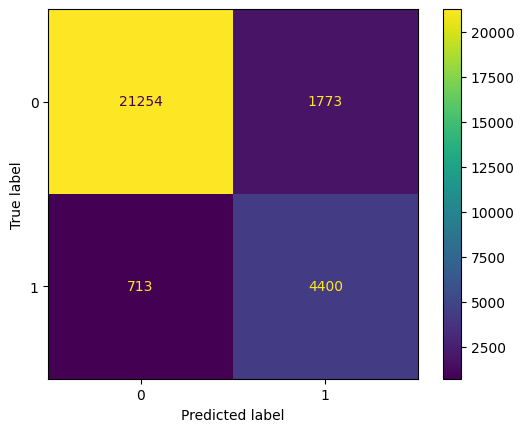

In [431]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(actuals, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [432]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(actuals, preds)
print("ROC-AUC:", roc_score)

ROC-AUC: 0.8917774830286858


In [433]:
torch.save(model.state_dict(), "depression_model.pth")

In [434]:
import joblib
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [435]:
test.shape

(93800, 19)

In [436]:
test.drop(columns=["Name","id"],inplace=True)

In [437]:
test["Working Professional or Student"] = test["Working Professional or Student"].fillna(
    test["Profession"].map({
        "Student": "Student",
        "Working Professional": "Unknown"
    })
)

In [438]:
test = top_k_encoder(test, 'City', 10)
test = top_k_encoder(test, 'Profession', 5) 
test = top_k_encoder(test, 'Sleep Duration', 4)
test = top_k_encoder(test, 'Dietary Habits', 3)
test = top_k_encoder(test, 'Dietary Habits', 3)
test = top_k_encoder(test, 'Degree', 5)

In [439]:
test=handle_structural_missing(test)

In [440]:
test=test.dropna()

In [441]:
test.isnull().sum()

Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
dtype: int64

In [ ]:

assert all(isinstance(step, tuple) for step in numeric_transformer.steps), "numeric_transformer steps must be tuples"
assert all(isinstance(step, tuple) for step in categorical_transformer.steps), "categorical_transformer steps must be tuples"

X_test = preprocessor.fit_transform(test)
X_test


array([[ 1.02298805, -0.44894988, -0.23496172, ...,  1.        ,
         0.        ,  1.        ],
       [ 1.42642812, -0.44894988, -0.23496172, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.02298805, -0.44894988,  0.91439081, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.31696439,  0.26146898, -1.38431425, ...,  1.        ,
         1.        ,  0.        ],
       [-1.3976524 , -0.44894988,  0.91439081, ...,  1.        ,
         0.        ,  1.        ],
       [ 0.2161079 , -0.44894988,  1.48906707, ...,  0.        ,
         1.        ,  0.        ]])

In [449]:
X_test_dense = X_test.toarray() if sparse.issparse(X_test) else X_test


X_test_tesor = torch.tensor(X_test_dense, dtype=torch.float32)



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4044\3204622346.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tesor = torch.tensor(X_test_dense, dtype=torch.float32)


In [450]:
model.eval()

import torch

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    outputs = model(X_test_tensor)
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.35).int()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4044\1535022490.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


In [452]:
submission = pd.DataFrame({
    "ID": test.index,   # or real ID column
    "Depression": preds.numpy().flatten()
})

submission.to_csv("submission.csv", index=False)